In [20]:
%load_ext autoreload
%autoreload 2  
from nrec_utils.occlusions.motion_vibration import MotionVibration
import cv2
import numpy as np
from matplotlib import pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


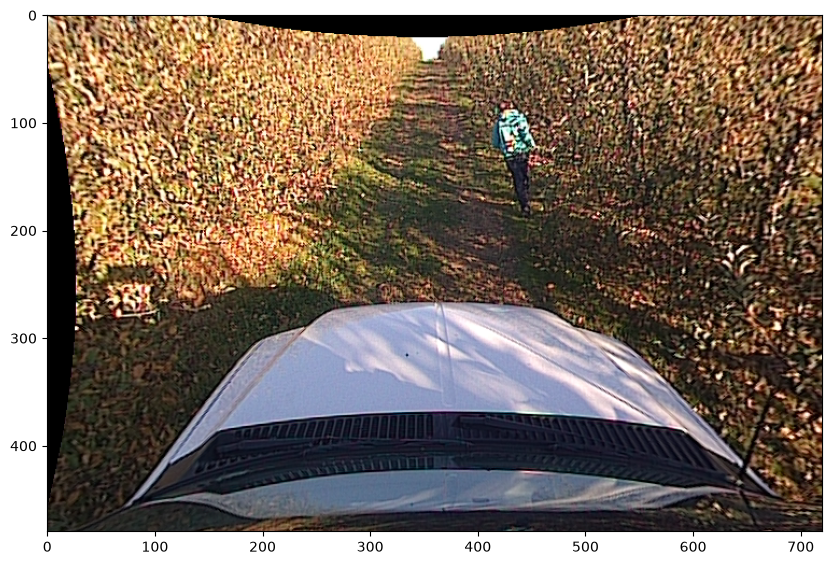

In [21]:
img_path=r'D:\AgriImages\NREC\apples_left_labeled_1\test\positive\2015.11Soergels\2015_11_09_1027_person_BrownJacket_SoergelB_Sunny_Row_StandingFrontalTireTracksPrimaryLog\Images\Image_0_0_1447082856.057.png'
img_path=r'D:\AgriImages\NREC\apples_left_labeled_2\train\positive\2015.11Soergels\2015_11_13_1435_movingPerson_GrayJacket_SoergelA_MiddayCloudy_Row_BentOverCrossCenterPrimaryLog\Images\Image_0_0_1447443347.028.png'
img_path=r'D:\AgriImages\NREC\apples_left_labeled_2\train\positive\2015.11Soergels\2015_11_16_1557_movingPerson_BlueHood_SoergelA_LateSunny_Row_ContinuousObsTrentonPrimaryLog\Images\Image_0_0_1447707464.740.png'

image1 = cv2.imread(img_path, cv2.IMREAD_COLOR)

# converting BGR to RGB
image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)

fig = plt.figure(figsize=(10, 10))
plt.imshow(image1)
plt.show()

Text(0, 0.5, 'estimated distance')

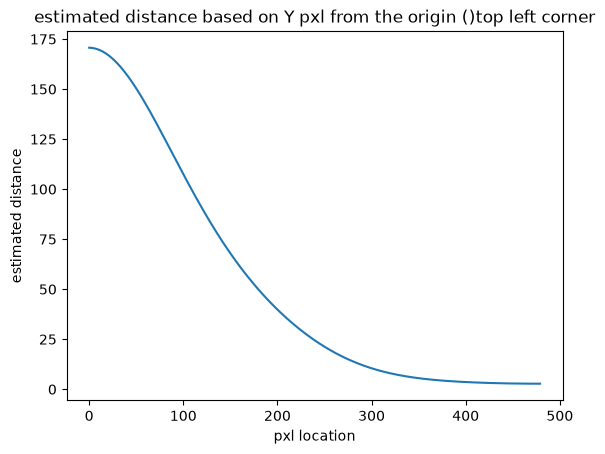

In [19]:
# Distance estimation
import  nrec_utils.occlusions.fog_occlusion as fog_occ
depth=fog_occ.fake_depth_map(image1)
plt.plot(depth[:,0])
plt.title("estimated distance based on Y pxl from the origin ()top left corner")
plt.xlabel("pxl location")
plt.ylabel("estimated distance")

INFO - creating occlusion instance of motionVibration


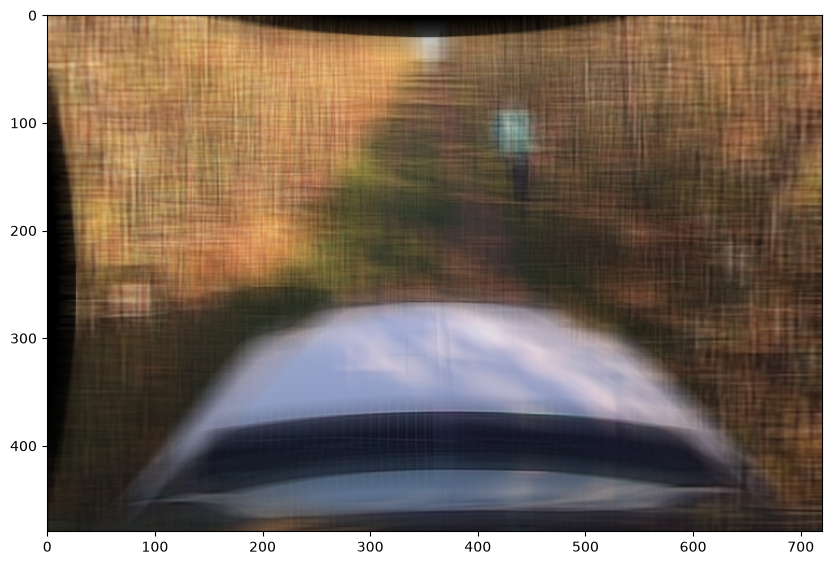

In [76]:
from nrec_utils.occlusions import MotionVibration
mv = MotionVibration(0.3)

mv_img = mv.generate_occluded_image(image1)
fig = plt.figure(figsize=(10, 10))
plt.imshow(mv_img)
#plt.show()


INFO - creating occlusion instance of fogEffect


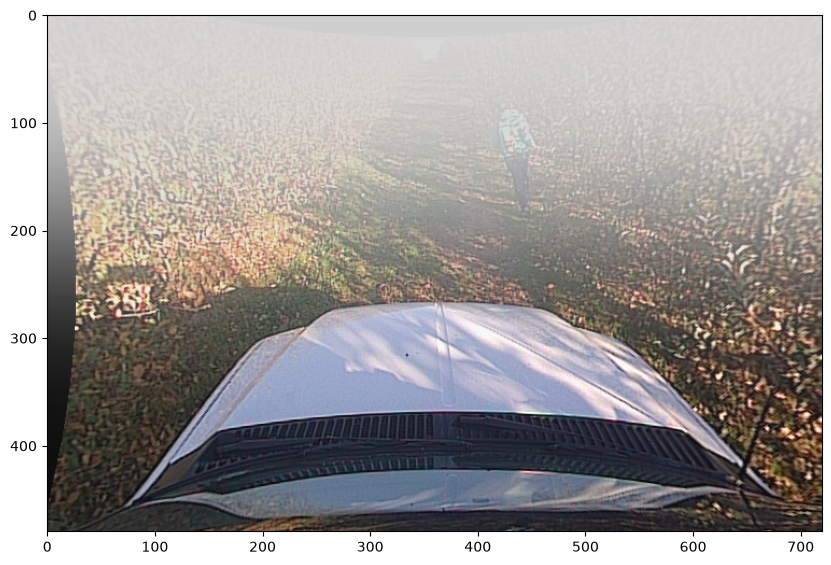

In [23]:
from nrec_utils.occlusions import Fog
fogg=Fog(0.2)
fog=fogg.generate_occluded_image(image1)
fig = plt.figure(figsize=(10, 10))
plt.imshow(fog)
plt.show()


In [ ]:
fig = plt.figure(figsize=(10, 10))
plt.imshow(mv_img)

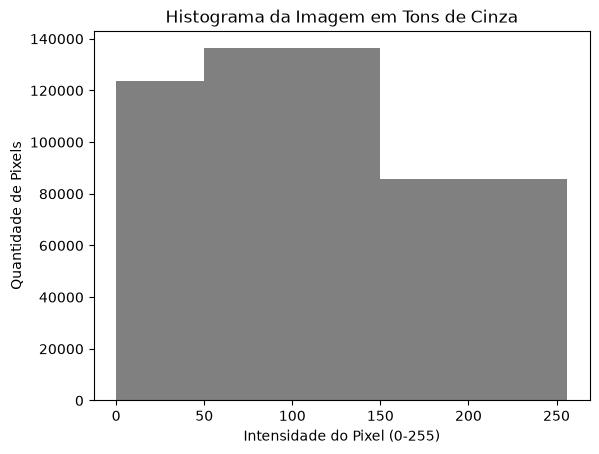

[13062     0     0   502]
[0.   0.25 0.5  0.75 1.  ]
Luminância global da imagem: 91.64 meangrayscale is 77.0


In [14]:

import random
def getIlluminationMapCheat( img: np.ndarray) -> np.ndarray: 
    T = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY);
    #T = color.rgb2gray(img)
    return T

T = getIlluminationMapCheat(image1)

hist,bins = np.histogram(T, bins=4, range=(0,1))


plt.hist(T.ravel(), bins=[0,50,150,256], range=[0, 255], color='gray')

# 3. Configurar títulos e exibir
plt.title("Histograma da Imagem em Tons de Cinza")
plt.xlabel("Intensidade do Pixel (0-255)")
plt.ylabel("Quantidade de Pixels")
plt.show()
#fig = plt.figure(figsize=(10, 10))
#plt.imshow(T,'gray')
#plt.show()
print(hist)
print(bins)
#illumination_bin = 
#print(np.argmax(illumination_bin))

#illumination2fogcolor = {0: (150, 180), 1: (180, 200), 2: (200, 240), 3: (200, 240)}
#fog_color = random.randint(illumination2fogcolor[illumination_bin][0],illumination2fogcolor[illumination_bin][1])
#fog_color

pesos = np.array([0.2126, 0.7152, 0.0722])
matriz_luminancia = np.dot(image1[..., :3], pesos)

luminancia_global = np.mean(matriz_luminancia)
print(f"Luminância global da imagem: {luminancia_global:.2f} meangrayscale is {np.median(T.ravel())}")


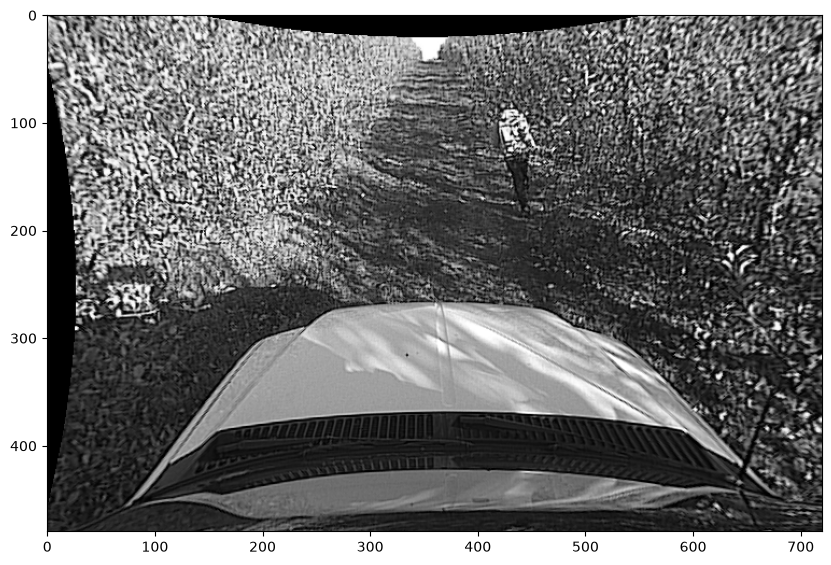

In [12]:
fig = plt.figure(figsize=(10, 10))
plt.imshow(T,'gray')

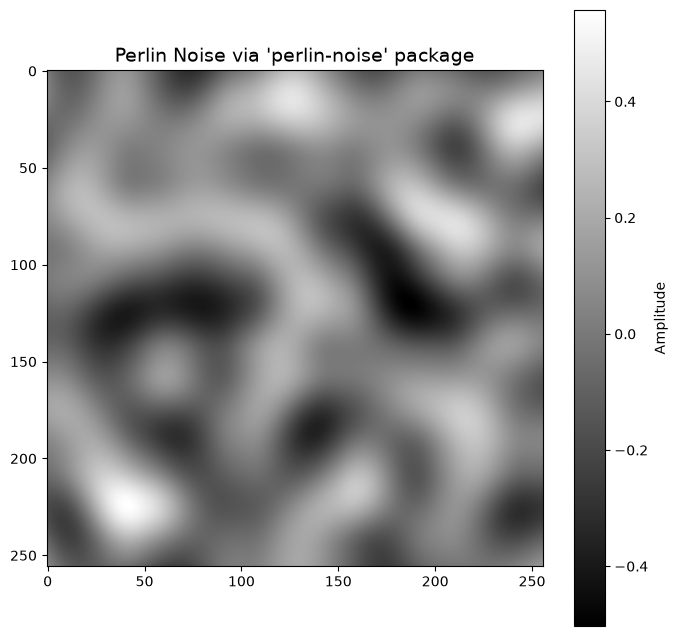

In [139]:
import matplotlib.pyplot as plt
import numpy as np
from perlin_noise import PerlinNoise

# 1. Initialize the PerlinNoise object
# 'octaves' controls the frequency/detail, 'seed' ensures reproducibility
noise_gen = PerlinNoise(octaves=2, seed=42)

# 2. Create a coordinate grid
width, height = 256, 256
x_scale = 100.0
y_scale = 100.0

noise_matrix = np.zeros((width, height))
for i in range(width):
    for j in range(height):
        # Pass coordinates as a list [x, y] to the noise generator instance
        noise_matrix[i][j] = noise_gen([i / x_scale, j / y_scale])

# 3. Plot the result
plt.figure(figsize=(8, 8))
plt.imshow(noise_matrix, cmap='gray')
plt.title("Perlin Noise via 'perlin-noise' package", fontsize=14)
plt.colorbar(label="Amplitude")
plt.axis('on')
plt.show()

In [147]:
def gen_perlin_2d(n_x, n_y, scale=1, **kwargs):
  
  # Create an array for holding Perlin noise
  # y coordinates correspond to the rows
  noise_gen = PerlinNoise(octaves=4, seed=42)
  perlin_data = np.zeros((n_y, n_x))
  
  # Largest dimension - use to scale values
  max_n=max(n_y, n_x)

  # Compute noise using indices of the array
  for i in range(n_y): 
    for j in range(n_x):
      perlin_data[i,j] = noise_gen([j/max_n * scale, i/max_n * scale])
      
  return perlin_data

In [150]:
def perlin_noise_map(H, W, octaves=4, seed=None, grid=64):
  # sample noise on a coarse grid (grid rows), then upscale to the image size
  noise = PerlinNoise(octaves=octaves, seed=seed)
  gh = grid
  gw = max(1, int(round(grid * W / H)))
  small = np.array(
    [[noise([i / gh, j / gw]) for j in range(gw)] for i in range(gh)],
    dtype=np.float32
  )
  return cv2.resize(small, (W, H), interpolation=cv2.INTER_CUBIC)  # values ~[-0.5, 0.5]

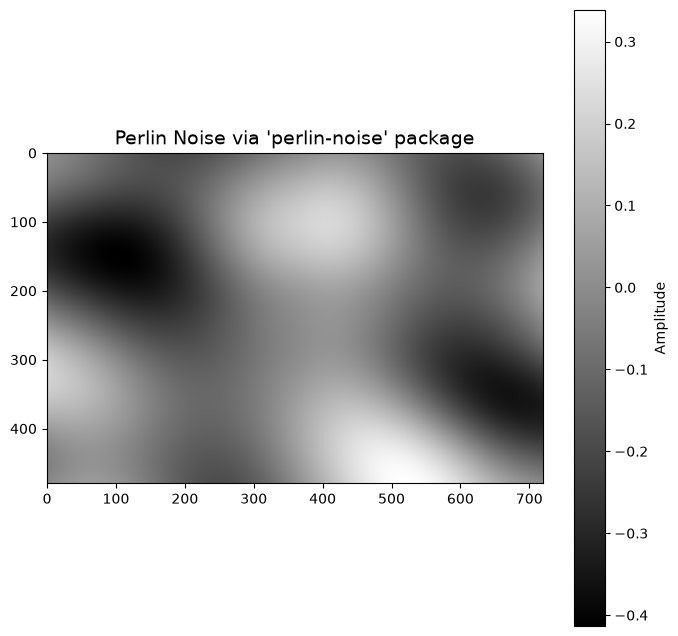

In [153]:
#noise = PerlinNoise(octaves=4, seed=48)
#noise()


n_x = 720
n_y = 480

# Generate data
perlin_data = gen_perlin_2d(n_x, n_y)
perlin_data=perlin_noise_map(480,720,octaves=2)

# 3. Plot the result
plt.figure(figsize=(8, 8))
plt.imshow(perlin_data, cmap='gray')
plt.title("Perlin Noise via 'perlin-noise' package", fontsize=14)
plt.colorbar(label="Amplitude")
plt.axis('on')
plt.show()